In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import  LinearRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [46]:
import pandas as pd

df = pd.read_parquet(
    "../data/green_tripdata_2026-05.parquet", 
    engine="pyarrow"
)

In [5]:
import os
print(os.getcwd())


c:\Users\start\projects\mlops-practitioner\notebooks


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44921 entries, 0 to 44920
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               44921 non-null  int32         
 1   lpep_pickup_datetime   44921 non-null  datetime64[us]
 2   lpep_dropoff_datetime  44921 non-null  datetime64[us]
 3   store_and_fwd_flag     39149 non-null  str           
 4   RatecodeID             39149 non-null  float64       
 5   PULocationID           44921 non-null  int32         
 6   DOLocationID           44921 non-null  int32         
 7   passenger_count        39149 non-null  float64       
 8   trip_distance          44921 non-null  float64       
 9   fare_amount            44921 non-null  float64       
 10  extra                  44921 non-null  float64       
 11  mta_tax                44921 non-null  float64       
 12  tip_amount             44921 non-null  float64       
 13  tolls_amount

In [36]:
df.head(10)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2026-05-01 00:02:02,2026-05-01 00:21:03,N,1.0,198,56,1.0,4.08,21.90,...,0.5,0.00,0.0,NaN,1.0,24.40,2.0,1.0,0.00,0.0
1,2,2026-05-01 00:30:22,2026-05-01 00:53:51,N,1.0,66,262,1.0,8.07,35.90,...,0.5,1.80,0.0,NaN,1.0,42.95,1.0,1.0,2.75,0.0
2,2,2026-05-01 00:30:17,2026-05-01 00:50:34,N,1.0,66,112,1.0,5.97,27.50,...,0.5,1.00,0.0,NaN,1.0,31.00,1.0,1.0,0.00,0.0
3,2,2026-05-01 00:05:49,2026-05-01 00:06:03,N,5.0,53,53,1.0,0.00,22.00,...,0.0,4.60,0.0,NaN,1.0,27.60,1.0,2.0,0.00,0.0
4,2,2026-05-01 00:45:47,2026-05-01 00:53:20,N,5.0,200,265,0.0,1.86,13.11,...,0.0,0.00,0.0,NaN,1.0,14.11,1.0,2.0,0.00,0.0
5,2,2026-05-01 00:13:10,2026-05-01 00:13:41,N,5.0,92,264,1.0,0.00,12.00,...,0.0,0.00,0.0,NaN,1.0,13.00,1.0,2.0,0.00,0.0
6,2,2026-05-01 00:42:21,2026-05-01 00:43:13,N,1.0,243,243,2.0,0.04,-3.00,...,-0.5,0.00,0.0,NaN,-1.0,-5.50,3.0,1.0,0.00,0.0
7,2,2026-05-01 00:42:21,2026-05-01 00:43:13,N,1.0,243,243,2.0,0.04,3.00,...,0.5,0.00,0.0,NaN,1.0,5.50,3.0,1.0,0.00,0.0
8,2,2026-05-01 00:32:20,2026-05-01 00:42:36,N,1.0,95,160,1.0,2.25,13.50,...,0.5,0.00,0.0,NaN,1.0,16.00,1.0,1.0,0.00,0.0
9,2,2026-04-30 23:54:33,2026-05-01 00:13:46,N,1.0,25,228,2.0,2.87,19.10,...,0.5,4.32,0.0,NaN,1.0,25.92,1.0,1.0,0.00,0.0


In [47]:
df['duration'] = df.lpep_dropoff_datetime  - df.lpep_pickup_datetime

In [48]:
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
df = df[(df['duration'] >= 1) & (df['duration'] <= 120)]

In [49]:

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [50]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,2,2026-05-01 00:02:02,2026-05-01 00:21:03,N,1.0,198,56,1.0,4.08,21.90,...,0.00,0.00,NaN,1.0,24.40,2.0,1.0,0.00,0.0,19.016667
1,2,2026-05-01 00:30:22,2026-05-01 00:53:51,N,1.0,66,262,1.0,8.07,35.90,...,1.80,0.00,NaN,1.0,42.95,1.0,1.0,2.75,0.0,23.483333
2,2,2026-05-01 00:30:17,2026-05-01 00:50:34,N,1.0,66,112,1.0,5.97,27.50,...,1.00,0.00,NaN,1.0,31.00,1.0,1.0,0.00,0.0,20.283333
4,2,2026-05-01 00:45:47,2026-05-01 00:53:20,N,5.0,200,265,0.0,1.86,13.11,...,0.00,0.00,NaN,1.0,14.11,1.0,2.0,0.00,0.0,7.550000
8,2,2026-05-01 00:32:20,2026-05-01 00:42:36,N,1.0,95,160,1.0,2.25,13.50,...,0.00,0.00,NaN,1.0,16.00,1.0,1.0,0.00,0.0,10.266667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44916,2,2026-05-31 21:06:04,2026-05-31 21:18:11,NaN,NaN,166,239,NaN,2.31,16.87,...,2.00,0.00,NaN,1.0,23.12,NaN,NaN,NaN,0.0,12.116667
44917,2,2026-05-31 21:20:00,2026-05-31 21:49:00,NaN,NaN,25,222,NaN,6.79,39.15,...,0.00,0.00,NaN,1.0,40.65,NaN,NaN,NaN,0.0,29.000000
44918,2,2026-05-31 22:11:20,2026-05-31 22:36:44,NaN,NaN,129,36,NaN,6.38,26.52,...,6.59,0.00,NaN,1.0,34.61,NaN,NaN,NaN,0.0,25.400000
44919,2,2026-05-31 23:08:05,2026-05-31 23:36:49,NaN,NaN,82,75,NaN,8.76,33.98,...,0.00,7.46,NaN,1.0,42.94,NaN,NaN,NaN,0.0,28.733333


In [57]:
train_dict = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dict)

y_train = df.duration.values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_predict = lr.predict(X_train)

rmse = root_mean_squared_error(y_pred=y_predict, y_true= y_train)
mae = mean_absolute_error(y_pred=y_predict, y_true= y_train)

print("Root Mean Squared Error: ",rmse )
print("Mean Absolute Error: ", mae)

Root Mean Squared Error:  10.660252491360778
Mean Absolute Error:  6.65324075430982


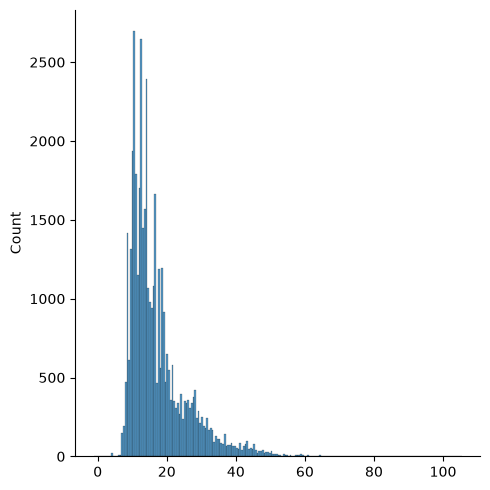

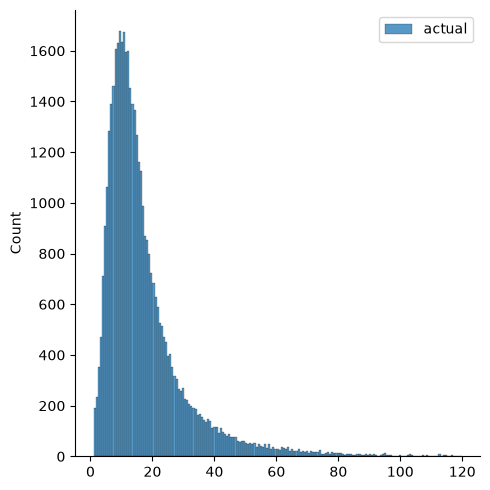

In [54]:
sns.displot(y_predict, label='prediction')
sns.displot(y_train, label='actual')

plt.legend()

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)
print(f"MSE: {root_mean_squared_error(y_test, y_pred):.4f}")

MSE: 8.1169


In [62]:
with open('lr_baseline.pkl', 'wb') as out_file:
    pickle.dump((dv, lr), out_file)

In [63]:
with open('rf_baseline.pkl', 'wb') as out_file:
    pickle.dump(regressor, out_file)